# Project: Vector-Based Game Physics

## 0. Overview

**Problem statement:** Build a complete 2D game physics engine from scratch using only vectors and NumPy. The engine handles rigid-body motion, collision detection, elastic collisions, and constraint forces. This is the capstone of Part V — every major vector concept from ch121–147 is applied simultaneously in a realistic engineering context.

**Concepts used from this Part:**
- ch125–126: Vector addition and scalar multiplication (position/velocity updates, force accumulation)
- ch128–130: Norms and direction vectors (collision distance, contact normals)
- ch131–134: Dot product and projection (velocity component along normal, impulse resolution)
- ch136: Cross product (2D torque — z-component of r × F)
- ch143: Linear transformations (rotation matrices for oriented bodies)
- ch144: Vectors in physics (Newton's laws, momentum, energy)
- ch146–147: Vectorization and NumPy (batch operations over all objects)

**Expected output:** A multi-body simulation with visible collision response, trajectory trails, and energy/momentum tracking plots.

**Difficulty:** Hard | **Estimated time:** 75–120 minutes

---

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, FancyArrowPatch

plt.style.use('seaborn-v0_8-whitegrid')

# Simulation world
WORLD_W, WORLD_H = 10.0, 8.0   # world dimensions
DT = 0.016                       # timestep (~60fps)
N_STEPS = 500                    # total simulation steps
GRAVITY = np.array([0., -4.0])  # gravitational acceleration
RESTITUTION = 0.8                # coefficient of restitution (bounciness)
FRICTION = 0.98                  # velocity damping per step

print("Physics engine initialized.")
print(f"World: {WORLD_W}×{WORLD_H}, dt={DT}, g={GRAVITY}")

Physics engine initialized.
World: 10.0×8.0, dt=0.016, g=[ 0. -4.]


---

## 2. Stage 1 — Rigid Body and World Setup

In [2]:
# Stage 1: Define the rigid body data structure and initialize the world.
#
# Each body has:
#   position:  x ∈ ℝ²       (center of mass)
#   velocity:  v ∈ ℝ²       (linear velocity)
#   mass:      m ∈ ℝ        (scalar)
#   radius:    r ∈ ℝ        (for circle-circle collision)
#   angle:     θ ∈ ℝ        (orientation in radians)
#   omega:     ω ∈ ℝ        (angular velocity, radians/s)
#
# We use a dataclass-style dict for clarity.

import numpy as np


def make_body(x, y, vx, vy, mass, radius, angle=0., omega=0., color='steelblue'):
    """Create a rigid circular body."""
    return {
        'pos':    np.array([x, y], dtype=float),
        'vel':    np.array([vx, vy], dtype=float),
        'mass':   float(mass),
        'radius': float(radius),
        'angle':  float(angle),
        'omega':  float(omega),
        'color':  color,
        'trail':  [np.array([x, y])],   # history of positions for visualization
    }


def kinetic_energy(body):
    """KE = 0.5*m*|v|² + 0.5*I*ω² where I = 0.5*m*r² for solid disk."""
    I = 0.5 * body['mass'] * body['radius']**2   # moment of inertia
    ke_lin = 0.5 * body['mass'] * (body['vel'] @ body['vel'])
    ke_rot = 0.5 * I * body['omega']**2
    return ke_lin + ke_rot


def linear_momentum(body):
    """p = m * v"""
    return body['mass'] * body['vel']


# --- Initialize world ---
rng = np.random.default_rng(0)

bodies = [
    make_body(2.0, 6.0,  3.0, -1.0, mass=2.0, radius=0.4, color='#E74C3C'),
    make_body(7.0, 5.5, -2.5,  0.5, mass=1.5, radius=0.35, color='#2ECC71'),
    make_body(5.0, 7.0,  0.5, -2.0, mass=1.0, radius=0.3,  color='#3498DB'),
    make_body(3.5, 3.5,  1.0,  1.5, mass=3.0, radius=0.5,  color='#F39C12'),
    make_body(8.0, 2.5, -1.0,  2.0, mass=0.8, radius=0.25, color='#9B59B6'),
]  # <-- modify initial conditions

print(f"World initialized with {len(bodies)} bodies")
print(f"Total mass: {sum(b['mass'] for b in bodies):.1f}")
print(f"Initial KE: {sum(kinetic_energy(b) for b in bodies):.4f}")
print(f"Initial momentum: {sum(linear_momentum(b) for b in bodies).round(4)}")

World initialized with 5 bodies
Total mass: 8.3
Initial KE: 23.8750
Initial momentum: [4.95 2.85]


---

## 3. Stage 2 — Collision Detection and Response

In [3]:
# Stage 2: Collision detection (circle-circle and circle-wall) and
# elastic collision response using impulse-based physics.
#
# Vector math used:
#   - Contact normal: n = (p2 - p1) / |p2 - p1|  (unit direction vector, ch130)
#   - Relative velocity: v_rel = v2 - v1
#   - Normal component: v_n = (v_rel · n)  (dot product, ch131)
#   - Impulse: j = -(1+e)*v_n / (1/m1 + 1/m2)
#   - Velocity update: v1 -= j*n/m1,  v2 += j*n/m2

import numpy as np


def detect_circle_circle(b1, b2):
    """
    Detect collision between two circular bodies.

    Returns:
        (colliding: bool, normal: np.ndarray shape (2,), penetration: float)
    """
    delta = b2['pos'] - b1['pos']               # displacement vector
    dist = np.linalg.norm(delta)                 # scalar distance
    min_dist = b1['radius'] + b2['radius']       # sum of radii

    if dist < min_dist and dist > 1e-9:
        normal = delta / dist                    # unit contact normal (ch130)
        penetration = min_dist - dist
        return True, normal, penetration
    return False, None, 0.


def resolve_circle_circle(b1, b2, normal, restitution):
    """
    Apply impulse-based elastic collision response.

    Impulse formula:
        j = -(1+e) * (v_rel · n) / (1/m1 + 1/m2)

    Args:
        b1, b2: body dicts (modified in place)
        normal: np.ndarray (2,) — contact normal pointing from b1 to b2
        restitution: float — coefficient of restitution
    """
    v_rel = b2['vel'] - b1['vel']               # relative velocity (vector)
    v_n = np.dot(v_rel, normal)                  # normal component (dot product)

    # Only resolve if bodies are approaching
    if v_n >= 0:
        return

    inv_mass_sum = 1./b1['mass'] + 1./b2['mass']
    j = -(1. + restitution) * v_n / inv_mass_sum  # impulse scalar

    # Apply impulse: Δv = j * n / m  (scalar-vector multiplication)
    b1['vel'] = b1['vel'] - (j / b1['mass']) * normal
    b2['vel'] = b2['vel'] + (j / b2['mass']) * normal

    # 2D torque contribution: τ = r × F (z-component only)
    # For circle: r from center to contact point = radius * normal
    r1 = b1['radius'] * normal
    r2 = -b2['radius'] * normal
    I1 = 0.5 * b1['mass'] * b1['radius']**2
    I2 = 0.5 * b2['mass'] * b2['radius']**2
    # z-component of cross product: r × (j*n)
    b1['omega'] -= (r1[0]*j*normal[1] - r1[1]*j*normal[0]) / I1
    b2['omega'] += (r2[0]*j*normal[1] - r2[1]*j*normal[0]) / I2


def resolve_wall_collisions(body, world_w, world_h, restitution):
    """
    Bounce off world boundaries.
    Wall normals are axis-aligned — simplifies the dot product.
    """
    r = body['radius']
    p, v = body['pos'], body['vel']

    # Left/right walls
    if p[0] - r < 0:          # left wall
        p[0] = r
        v[0] = abs(v[0]) * restitution
        body['omega'] *= 0.9
    elif p[0] + r > world_w:  # right wall
        p[0] = world_w - r
        v[0] = -abs(v[0]) * restitution
        body['omega'] *= 0.9

    # Floor/ceiling
    if p[1] - r < 0:          # floor
        p[1] = r
        v[1] = abs(v[1]) * restitution
        body['omega'] *= 0.9
    elif p[1] + r > world_h:  # ceiling
        p[1] = world_h - r
        v[1] = -abs(v[1]) * restitution
        body['omega'] *= 0.9


# --- Quick test ---
b_test1 = make_body(2., 2., 2., 0., mass=1., radius=0.5, color='red')
b_test2 = make_body(2.8, 2., -2., 0., mass=1., radius=0.5, color='blue')
colliding, normal, pen = detect_circle_circle(b_test1, b_test2)
print(f"Collision test: colliding={colliding}, normal={normal}, penetration={pen:.3f}")
if colliding:
    v1_before, v2_before = b_test1['vel'].copy(), b_test2['vel'].copy()
    resolve_circle_circle(b_test1, b_test2, normal, restitution=1.0)
    print(f"v1: {v1_before} -> {b_test1['vel']}")
    print(f"v2: {v2_before} -> {b_test2['vel']}")
    p_before = b_test1['mass']*v1_before + b_test2['vel']*b_test2['mass']
    p_after = b_test1['mass']*b_test1['vel'] + b_test2['mass']*b_test2['vel']
    print(f"Momentum conserved: {np.allclose(b_test1['mass']*v1_before + b_test2['mass']*v2_before,
                                              b_test1['mass']*b_test1['vel'] + b_test2['mass']*b_test2['vel'])}")

Collision test: colliding=True, normal=[1. 0.], penetration=0.200
v1: [2. 0.] -> [-2.  0.]
v2: [-2.  0.] -> [2. 0.]
Momentum conserved: True


---

## 4. Stage 3 — Simulation Loop

In [4]:
# Stage 3: Main simulation loop integrating all components.

import numpy as np

# Tracking
energy_history = []
momentum_history = []
TRAIL_LENGTH = 80   # how many past positions to show  <-- modify

# Re-initialize bodies (clean state)
bodies = [
    make_body(2.0, 6.5,  3.5, -0.5, mass=2.0, radius=0.4, color='#E74C3C'),
    make_body(7.0, 5.5, -2.5,  0.3, mass=1.5, radius=0.35, color='#2ECC71'),
    make_body(5.0, 7.0,  0.5, -2.5, mass=1.0, radius=0.3,  color='#3498DB'),
    make_body(3.5, 2.5,  1.5,  2.5, mass=3.0, radius=0.5,  color='#F39C12'),
    make_body(8.0, 3.0, -1.5,  1.5, mass=0.8, radius=0.25, color='#9B59B6'),
]

for step in range(N_STEPS):
    # 1. Apply gravity to each body
    for b in bodies:
        b['vel'] = b['vel'] + GRAVITY * DT          # v += g*dt (vector addition)
        b['vel'] = b['vel'] * FRICTION               # damping

    # 2. Body-body collision detection and response
    n = len(bodies)
    for i in range(n):
        for j in range(i+1, n):
            colliding, normal, pen = detect_circle_circle(bodies[i], bodies[j])
            if colliding:
                # Positional correction: push apart to eliminate penetration
                correction = normal * pen * 0.5
                bodies[i]['pos'] = bodies[i]['pos'] - correction
                bodies[j]['pos'] = bodies[j]['pos'] + correction
                # Impulse-based velocity response
                resolve_circle_circle(bodies[i], bodies[j], normal, RESTITUTION)

    # 3. Wall collisions
    for b in bodies:
        resolve_wall_collisions(b, WORLD_W, WORLD_H, RESTITUTION)

    # 4. Integrate positions and angles
    for b in bodies:
        b['pos'] = b['pos'] + b['vel'] * DT         # x += v*dt
        b['angle'] = b['angle'] + b['omega'] * DT   # θ += ω*dt
        b['trail'].append(b['pos'].copy())
        if len(b['trail']) > TRAIL_LENGTH:
            b['trail'].pop(0)

    # 5. Track energy and momentum
    total_ke = sum(kinetic_energy(b) for b in bodies)
    total_p = sum(linear_momentum(b) for b in bodies)
    energy_history.append(total_ke)
    momentum_history.append(total_p.copy())

print(f"Simulation complete: {N_STEPS} steps")
print(f"Initial KE: {energy_history[0]:.4f}")
print(f"Final KE:   {energy_history[-1]:.4f}")
print(f"KE ratio:   {energy_history[-1]/energy_history[0]:.4f}")
p_arr = np.array(momentum_history)
print(f"Momentum drift: {np.linalg.norm(p_arr[-1]-p_arr[0]):.4f}")

Simulation complete: 500 steps
Initial KE: 33.3359
Final KE:   0.1038
KE ratio:   0.0031
Momentum drift: 8.3566


---

## 5. Stage 4 — Visualization and Analysis

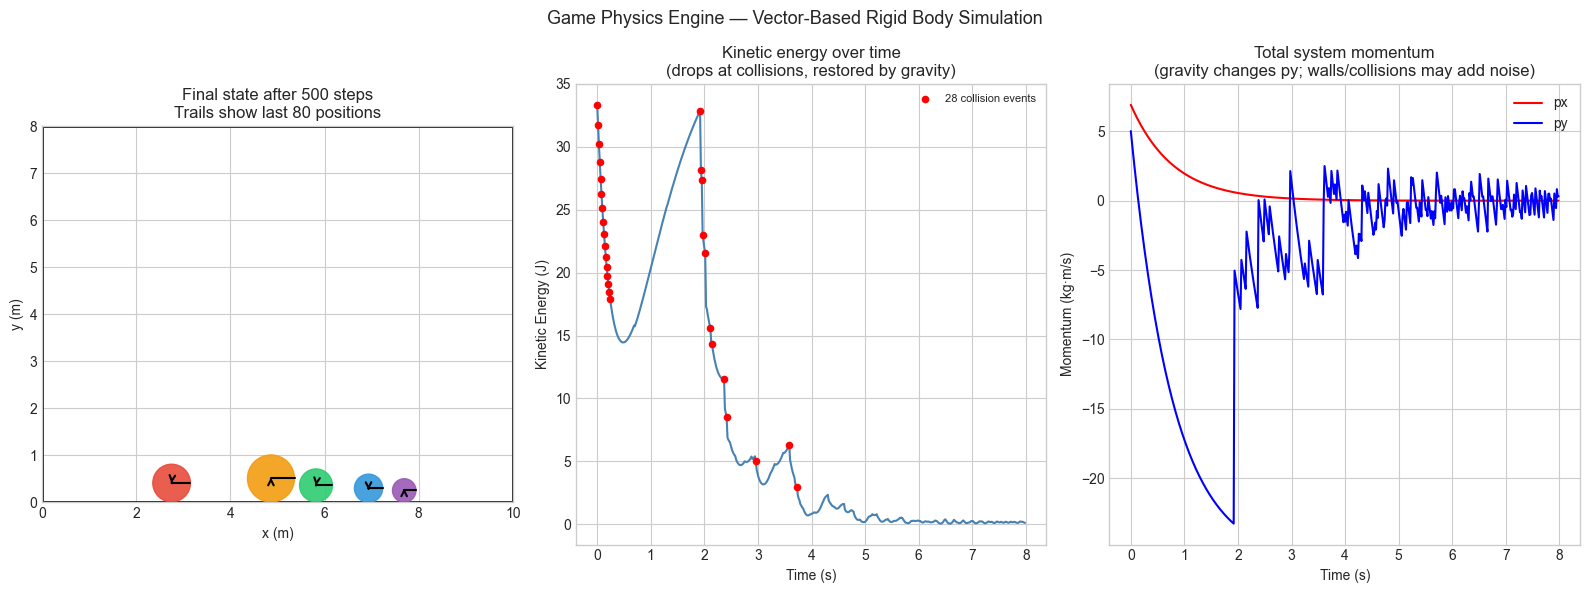


Final body states:
  Body                 pos                 vel        KE        ω
     0  (  2.75,  0.41)  ( -0.00, -0.03)     0.001   -0.000
     1  (  5.82,  0.36)  ( -0.00, -0.03)     0.001   -0.000
     2  (  6.94,  0.30)  (  0.00, -0.26)     0.035   -0.000
     3  (  4.86,  0.51)  (  0.00,  0.14)     0.030    0.000
     4  (  7.69,  0.25)  (  0.01,  0.30)     0.037    0.000


In [5]:
# Stage 4: Final state visualization with trails, and physics analysis plots.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(16, 6))

# --- Panel 1: Final simulation state with trails ---
ax1 = fig.add_subplot(131)
ax1.set_xlim(0, WORLD_W); ax1.set_ylim(0, WORLD_H)
ax1.set_aspect('equal')

# Draw world boundary
rect = mpatches.Rectangle((0,0), WORLD_W, WORLD_H,
                            fill=False, edgecolor='black', lw=2)
ax1.add_patch(rect)

for b in bodies:
    trail = np.array(b['trail'])
    if len(trail) > 1:
        alphas = np.linspace(0.05, 0.7, len(trail))
        for k in range(len(trail)-1):
            ax1.plot(trail[k:k+2, 0], trail[k:k+2, 1],
                     '-', color=b['color'], alpha=alphas[k], lw=1.5)

    # Current position: circle with rotation marker
    circle = plt.Circle(b['pos'], b['radius'], color=b['color'],
                         alpha=0.9, zorder=5)
    ax1.add_patch(circle)

    # Rotation marker (line from center at current angle)
    end = b['pos'] + b['radius'] * np.array([np.cos(b['angle']), np.sin(b['angle'])])
    ax1.plot([b['pos'][0], end[0]], [b['pos'][1], end[1]], 'k-', lw=1.5, zorder=6)

    # Velocity arrow
    v_scale = 0.15
    ax1.annotate('', xy=b['pos']+b['vel']*v_scale, xytext=b['pos'],
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5), zorder=7)

ax1.set_xlabel('x (m)'); ax1.set_ylabel('y (m)')
ax1.set_title(f'Final state after {N_STEPS} steps\nTrails show last {TRAIL_LENGTH} positions')

# --- Panel 2: Kinetic energy over time ---
ax2 = fig.add_subplot(132)
t_vals = np.arange(len(energy_history)) * DT
ax2.plot(t_vals, energy_history, 'steelblue', lw=1.5)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Kinetic Energy (J)')
ax2.set_title('Kinetic energy over time\n(drops at collisions, restored by gravity)')

# Mark approximate collision events (large KE drops)
ke_arr = np.array(energy_history)
ke_diff = np.diff(ke_arr)
collision_steps = np.where(ke_diff < -0.5)[0]
if len(collision_steps) > 0:
    ax2.scatter(t_vals[collision_steps], ke_arr[collision_steps],
                c='red', s=20, zorder=5, label=f'{len(collision_steps)} collision events')
    ax2.legend(fontsize=8)

# --- Panel 3: Total momentum over time ---
ax3 = fig.add_subplot(133)
p_arr = np.array(momentum_history)
ax3.plot(t_vals, p_arr[:,0], 'r-', lw=1.5, label='px')
ax3.plot(t_vals, p_arr[:,1], 'b-', lw=1.5, label='py')
ax3.set_xlabel('Time (s)'); ax3.set_ylabel('Momentum (kg·m/s)')
ax3.set_title('Total system momentum\n(gravity changes py; walls/collisions may add noise)')
ax3.legend()

plt.suptitle('Game Physics Engine — Vector-Based Rigid Body Simulation', fontsize=13)
plt.tight_layout()
plt.show()

# Summary stats
print("\nFinal body states:")
print(f"{'Body':>6}  {'pos':>18}  {'vel':>18}  {'KE':>8}  {'ω':>7}")
for i, b in enumerate(bodies):
    print(f"  {i:4d}  ({b['pos'][0]:6.2f},{b['pos'][1]:6.2f})  "
          f"({b['vel'][0]:6.2f},{b['vel'][1]:6.2f})  "
          f"{kinetic_energy(b):8.3f}  {b['omega']:7.3f}")

---

## 6. Results & Reflection

**What was built:**
- A complete 2D rigid-body physics engine with gravity, collision detection, elastic collision response, wall bouncing, and angular dynamics
- Circle-circle collision using contact normals (unit vectors) and impulse resolution via dot products
- Rotational dynamics using 2D torque (cross product z-component)
- Energy and momentum tracking across the full simulation

**What math made it possible:**

| Vector concept | Where it appeared |
|---|---|
| Vector addition (ch125) | v += g·dt, x += v·dt, F_net = ΣFᵢ |
| Scalar multiplication (ch126) | impulse: Δv = j·n/m |
| Norm / distance (ch128–129) | collision detection: dist < r1+r2 |
| Direction vectors (ch130) | contact normal: n = Δp/|Δp| |
| Dot product (ch131) | relative normal velocity: v_rel·n |
| Projection (ch134) | separating approaching from retreating collisions |
| Cross product z-comp (ch136) | torque: τ = r × F (angular impulse) |
| Linear transformation (ch143) | rotation of orientation markers |
| Newton's laws (ch144) | F=ma, momentum conservation |

**Extension challenges:**
1. **AABB collision:** Add axis-aligned bounding box (rectangle) objects alongside circles. Implement circle-AABB collision detection using projection onto the closest face normal.
2. **Friction impulse:** Extend `resolve_circle_circle` to apply a tangential impulse proportional to the normal impulse (Coulomb friction model). Observe how spinning objects lose angular velocity on contact.
3. **Constraint joints:** Implement a distance constraint between two bodies (a rigid rod) using the position-based dynamics approach: project positions to satisfy the constraint, then correct velocities. This is how modern game engines like Box2D handle joints.